---

# LESSON 24: GROUPPED BAR CHARTS

---

>---
>You can create a **grouped bar chart** by reducing the width of each series and shifting them evenly around their corresponding label
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)

df = (df
    .assign(price_range = pd.cut(x=df.median_active_list_price,
                                 bins=[0, 400000, 600000, 900000000],
                                 labels=['0-400k', '400k-600k', '600k+']),
            state = df.region_name.str[-2:])
)

fixed_date = pd.to_datetime('2021-08-01')
df = (df
    .query("period_end == @fixed_date and state.isin(['CA', 'OR', 'WA'])").pivot_table(index='price_range', columns='state', 
                                                    values='inventory', aggfunc='sum', observed=False))
df.head()

state,CA,OR,WA
price_range,,,
0-400k,4267.0,1074.0,2143.0
400k-600k,13877.0,4711.0,4858.0
600k+,35146.0,1228.0,3649.0


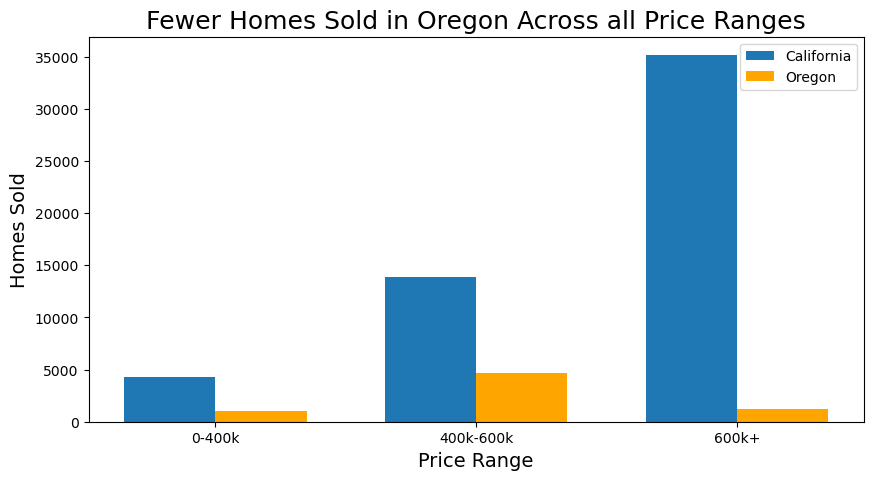

In [3]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

width=0.35
x = np.arange(3) # Length of index

ax.bar(x - width/2, df.CA,
       width=width, label='California')

ax.bar(x + width/2, df.OR, 
        width=width, label='Oregon',
        color='orange')

ax.set_title('Fewer Homes Sold in Oregon Across all Price Ranges', fontsize=18)
ax.set_xlabel('Price Range', fontsize=14)
ax.set_ylabel('Homes Sold', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(df.index)

ax.legend()
plt.show()

<br><br>

---
---


## LABORATORY

In [4]:
df.head()

state,CA,OR,WA
price_range,,,
0-400k,4267.0,1074.0,2143.0
400k-600k,13877.0,4711.0,4858.0
600k+,35146.0,1228.0,3649.0


<br><br>

---

### MATPLOTLIB-API PLOT

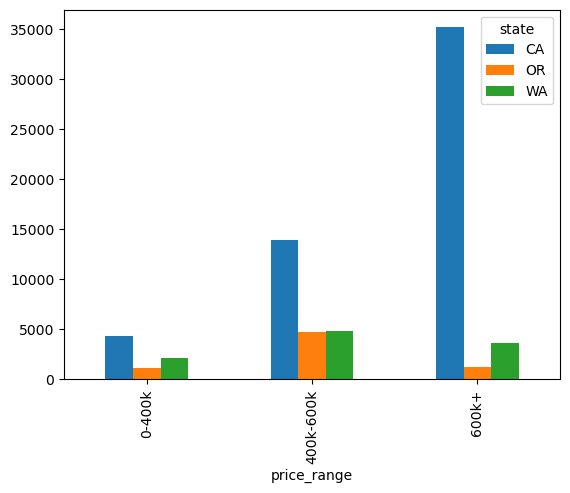

In [5]:
# Matplotlib API - Plot
df.plot.bar()
plt.show()

<br><br>

---

### SEABORN PLOT

In [6]:
df2 = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)

df2 = (df2
    .assign(price_range = pd.cut(x=df2.median_active_list_price,
                                 bins=[0, 400000, 600000, 900000000],
                                 labels=['0-400k', '400k-600k', '600k+']),
            state = df2.region_name.str[-2:])
)

df2 = (df2
    .query("state.isin(['CA', 'OR', 'WA'])"))

df2.head()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply,price_range,state
4,"Sacramento County, CA",2020-06-22,2020-09-13,5107.0,1729.0,2206.0,27.5,445540.9,5.235794,400k-600k,CA
17,"Garfield County, WA",2019-06-17,2019-09-08,7.0,9.0,10.0,52.7,152666.6,9.333333,0-400k,WA
24,"Gilliam County, OR",2018-06-18,2018-09-09,3.0,9.0,9.0,95.6,143037.5,9.000000,0-400k,OR
92,"Klickitat County, WA",2017-04-17,2017-07-09,48.0,53.0,58.0,87.2,326237.5,16.193434,0-400k,WA
117,"Jefferson County, WA",2017-02-06,2017-04-30,138.0,177.0,190.0,127.8,404637.5,22.486617,400k-600k,WA


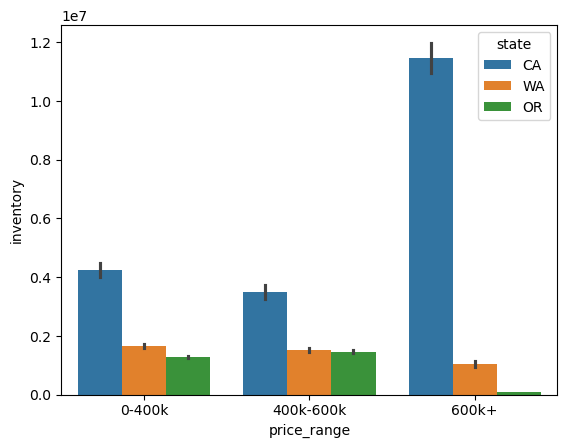

In [7]:
sns.barplot(data=df2, x='price_range', y='inventory', hue='state', estimator=sum)
plt.show()

<br><br>

---

### MATPLOTLIB - OBJECT ORIENTED

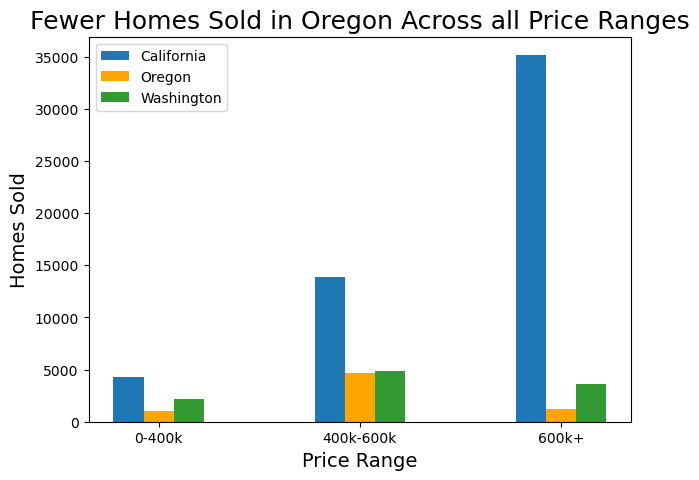

In [13]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

width=0.15
x = np.arange(3) # Length of index

ax.bar(x - width, df.CA,
       width=width, label='California')

ax.bar(x, df.OR, 
        width=width, label='Oregon',
        color='orange')

ax.bar(x + width, df.WA, 
       width=width, label='Washington',
       color='green', alpha=0.8)

ax.set_title('Fewer Homes Sold in Oregon Across all Price Ranges', fontsize=18)
ax.set_xlabel('Price Range', fontsize=14)
ax.set_ylabel('Homes Sold', fontsize=14)

ax.set_xticks(x) # it places the marker of "x_label"
ax.set_xticklabels(df.index)

ax.legend()
plt.show()